# Logistic Regression:

Is a GLM that uses for binary, multinomial, and multilabel classification tasks. We have two types of classification:
- Soft Classification
- Hard Classification

Logistic Regression can do soft classification cause it has a probability-like output and by choosing a threshold we hard classified the output label.

## Main Components:
- **Random Component:** Binomial Distribution
- **Systematic Component:** Linear Predictor
- **Link Function:** Logit Function

## Mathematics:

**The linear predictor:**

$ z = \omega_1x_1 + \omega_2x_2 + \omega_3x_3 + ... + \epsilon $

- **z** is the linear predictor output.
- **$\omega$** is the linear model's weight.
- **x** is the feature.

**The link function:**

$ \text{logit(p)} = ln(\frac{p}{1 - p}) = z $

--> $ \text{Sigmoid(z)} = \frac{1}{1 + \exp^{-z}} = \frac{1}{1 + \exp^{-(\omega_1x_1 + \omega_2x_2 + \omega_3x_3 + ... + \epsilon)}} = p $

- **p** is the probability of success.

So in this model to expand the linear regression concept we assume the linear relationship between features and the log-odds of the output. 

**Assumption:** z - logit(p) --> has a linear relationship

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid Function
def sigmoid(z: float) -> np.ndarray:
	"""Computes the Sigmoid function.

	:param z: Is the linear predictor output.
	:return: Is the probability of the success.
	"""
	return 1 / (1 + np.exp(-z))

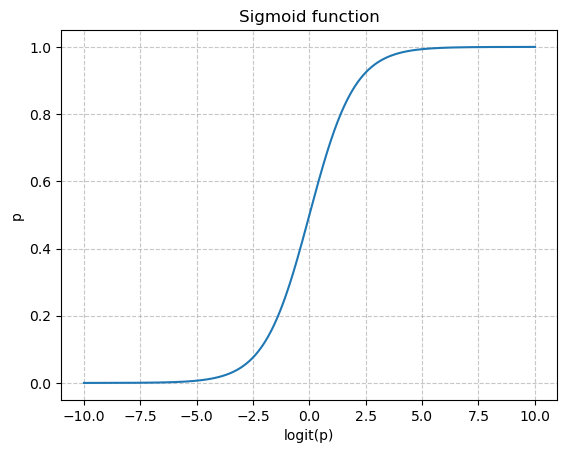

In [2]:
# Sigmoid function visualization
x = np.linspace(-10, 10, 1000)
y = sigmoid(x)

fig, ax = plt.subplots()

ax.plot(x, y)
ax.set(
    title="Sigmoid function",
    xlabel="logit(p)",
    ylabel="p"
)
ax.grid(True, linestyle="--", alpha=0.7)

> **Odds:** Is the rate of the probability of success with respect to the probability of failure.
>
> $ \text{Odds} = \frac{p}{1 - p}$

> **Log-Odds:** Log-odds is the logarithm of the odds of the probability.
>
> $ \text{Log-Odds} = \log(\frac{p}{1 - p}) $

These two concepts are import because of the interpretability of the Logistic Regression model. A coefficient of the Logistic Regression model shows the change of Log-Odds in the output.

> **Pro Tip:** think of the coefficients as the "*importance score*" for your features.

In [3]:
# Odds and Log-Odds functions
def odds(probability):
    return probability / (1 - probability)

def log_odds(probability):
    return np.log(odds(probability))

In [4]:
# example:
# linear predictor output: 0.1
z = 0.1
p = sigmoid(z)
print(f"Probability: {p:.3f}")

odds_ = odds(p)
print(f"Odds: {odds_:.3f}")
# keeping all other coefficients unchange the odds of the succession for the output becomes 10.5
# percent more

log_odds_ = log_odds(p)
print(f"Log-Odds: {log_odds_}")

Probability: 0.525
Odds: 1.105
Log-Odds: 0.10000000000000007


## Cons & Pros:

**Advantages of the Logistic Regression Model:**

- Interpretability
- Simplicity
- Efficiency
- No Normality Assumption of errors
- Probability-like Output
- Handles Multi-Class Classification --> OVR, Softmax

**Disadvantages of the Logistic Regression Model:**

- Vulnerability to Outliers
- Assumes Linear Relationship
- Can't Capture complex Non-Linear Pattern --> use: Random Forest, Neural Networks, SVMs, ...
- Assumes Independence of Features
- Prone to Overfitting in High Dimensional Data

## Assumptions

- Binary target variable (binomial distribution fits the target variable)
- Linear relationship between *linear predictor* & $\text{logit}(p)$
- Independece of observations
- Homoscedasticity

## Logistic Regression Model Code from Scratch:

For this algorithm we use **MLE** (**Maximum Likelihood Estimation**) to estimate the parameters and then we calculate the gradient of the cost function we found from the MLE, we don't use it's close form answer and we use optimization techniques like **Batch Gradient Descent** or **Mini Batch Gradient Descent** to calculate the weights vector by updating beta using gradient descent update rule.

**Cost Function:**

$$
	Likelihood:
	L(\beta) = \prod_{i=1}^n p_i^{y_i}(1-p_i)^{1-y_i}
$$
$$
	Log-Likelihood:
	\ell(\beta) = \sum_{i=1}^n [y_i \ln(p_i) + (1-y_i) \ln(1-p_i)]
$$

**Gradient:**

$$
	Gradient:
	\nabla \ell(\beta) = X^T(y - p)
$$
- **X** is the features matrix and it's $ [n * m] $. (n: number of samples, m: number of features)
- **y** is the labels vector and it's $ [n * 1] $.
- **p** is the probability of the predicted label and it's $ [n * 1] $

In [5]:
# Coding model from scratch:
import numpy as np

# sigmoid function
def sigmoid(z: float) -> np.ndarray:
    """Computes the sigmoid function.

	:param z: output of the linear predictor
	:return: the probability like output of the sigmoid function
	"""
    return 1 / (1 + np.exp(-z)) 

# gradient of the cost funtion (MLE)
def compute_gradient_logistic(
          X: np.ndarray, y:np.ndarray, beta:np.ndarray
) -> np.ndarray:
    """Computes the gradient of log-likelihood with respect to beta.

	:param X: Features. (Add intercept if needed)
	:param y: Target variable.
	:param beta: Weights array.
	:return: The gradient of the log-likelihood with respect to beta.
	"""
    n = X.shape[0]
    p = sigmoid(X @ beta) # probability for each sample
    return (1 / n) * X.T @ (p - y) # dim: n*1

# Defining the cost function (MLE)
def compute_cost_logistic(X, y, beta):
    """Computes the cost of the model in the optimization process.

	:param X: Features. (Add intercept if needed)
	:param y: Target variable.
	:param beta: Weights array.
	:return: The cost of the model.
	"""
    n = X.shape[0]
    p = sigmoid(X @ beta)
    return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p)) / n

In [6]:
def batch_gradient_descent_logistic(
        X: np.ndarray, y: np.ndarray,
        learning_rate : float = 0.1, num_epochs : int = 1000
) -> np.ndarray:
    """Logistic Regression Model.
    
    This is code for learning purposes and using batch gradient descent
    optimization technique trains a logistic regression model to model
    a binary classification. 

	:param X: Features arrray. (Add intercept if needed)
	:param y: Target variable
	:param learning_rate: The learning rate for the gradient descent
    	optimization update section, defaults to 0.1
	:param num_epochs: Number of the times the gradient descent optimization
    	algorithm runs to reach the optimized weights that make the cost function
    	to be its minimum value, defaults to 1000
	:return: Weights array
	"""
    assert y.shape == (X.shape[0], 1), "y is one dimensional. reshape it."
    
    n, m = X.shape
    beta = np.zeros((m, 1))
    
    for _ in range(num_epochs):
        shuffled_indices = np.random.permutation(n)
        X_shuffled = X[shuffled_indices]
        y_shuffled = y[shuffled_indices]
        
        gradient = compute_gradient_logistic(X_shuffled, y_shuffled, beta)
        beta -= learning_rate * gradient
        
    return beta

# The mini batch gradient descent full Logistic Regression model
def mini_batch_gradient_descent_logistic(
        X: np.ndarray, y: np.ndarray, learning_rate : float = 0.1,
		num_epochs : int = 1000, batch_size : int = 32
) -> (np.ndarray, list): # type: ignore
    """Logistic Regression model using mini batch gradient descent.
    
    This function trains a Logistic Regression model using the mini
    batch gradient descent optimization algoritm.

	:param X: Features arrray. (Add intercept if needed)
	:param y: Target variable
	:param learning_rate: The learning rate for the gradient descent
    	optimization update section, defaults to 0.1
    :param batch_size: Size of the batch that the optimization algorithm
		uses in every go to update the weights
	:param num_epochs: Number of the times the gradient descent optimization
    	algorithm runs to reach the optimized weights that make the cost function
    	to be its minimum value, defaults to 1000
	:return: Weights array
	"""
    assert y.shape == (X.shape[0], 1), "y is one dimensional. reshape it."
    
    n, m = X.shape
    beta = np.zeros((m, 1))
    cost_history = []
    
    for _ in range(num_epochs):
        shuffled_indices = np.random.permutation(n)
        X_shuffled = X[shuffled_indices]
        y_shuffled = y[shuffled_indices]
        
        for i in range(0, n, batch_size):
            xi = X_shuffled[i:i + batch_size]
            yi = y_shuffled[i:i + batch_size]
            gradient = compute_gradient_logistic(xi, yi, beta)
            beta -= learning_rate * gradient

        cost = compute_cost_logistic(X, y, beta)
        cost_history.append(cost)

    return beta, cost_history

In [7]:
import numpy as np

np.random.seed(0)

# Generate random data
n_samples = 1000
n_features = 2

X = np.random.randn(n_samples, n_features)

# Create a decision boundary with some noise
boundary = X[:, 0] + X[:, 1] + np.random.normal(0, 0.5, n_samples)

# Assign labels based on the noisy boundary
y = (boundary > 0).astype(int).reshape(-1, 1)

# Print class distribution
print("Class distribution:")
print(np.bincount(y.flatten()))

Class distribution:
[516 484]


Weights: [[-0.30531003]
 [ 4.48633809]
 [ 4.351934  ]]
--------------------------------------------------


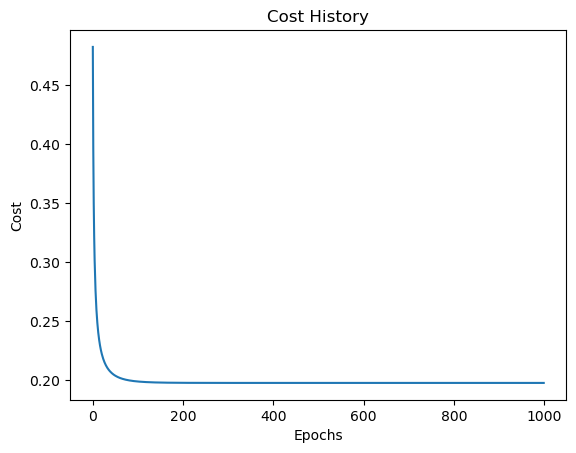

In [8]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])

beta, cost_history = mini_batch_gradient_descent_logistic(X_train, y_train)

print(f"Weights: {beta}")
print("-" * 50)

fig, ax = plt.subplots()
ax.plot(cost_history)
ax.set(
    title="Cost History",
    ylabel="Cost",
    xlabel="Epochs"
)
plt.show()

> **Note:** To avoid overfitting it's a good practice to stop the learning of the model on the epoch 150 for example, We can see that after epoch 150 there is no meaningful improvement in the cost of the model and the model is overfitting to the data after this epoch and to make out model do better on the unseen data and generalize to the unseen data data well we should stop the training earlier.


```python
# sudo-code to hard classify the labels using custom threshold
p = log_reg.predict_proba(X_test_scaled)
labels = p[:, 1] > 0.5

y_pred = []
for label in labels:
    if label:
        y_pred.append(1)
    else:
        y_pred.append(0)

>>> y_pred
```

In [102]:
# scikit-learn example:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score, recall_score,
    roc_curve, roc_auc_score, precision_recall_curve
)

# loading dataset
data = datasets.load_breast_cancer(as_frame=True)

X = data['data'].filter(regex="mean|worst|target").to_numpy()
y = data.target.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.fit_transform(X_val)

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

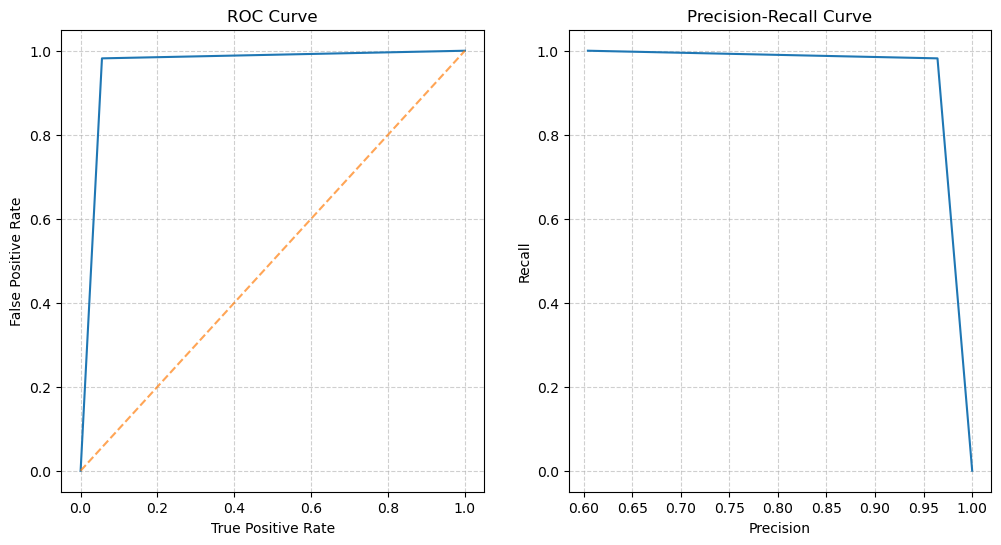

In [104]:
y_pred_val = log_reg.predict(X_val_scaled)

# print(classification_report(y_true=y_val, y_pred=y_pred_val))

fpr, tpr, _ = roc_curve(y_true=y_val, y_score=y_pred_val)
precision_, recall_, _ = precision_recall_curve(y_true=y_val, y_score=y_pred_val)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))

ax1.plot(fpr, tpr)
ax1.plot((0, 1), linestyle="--", alpha=0.7)

ax1.set(
    title="ROC Curve",
    xlabel="True Positive Rate",
    ylabel="False Positive Rate",
)

ax2.plot(precision_, recall_)

ax2.set(
    title="Precision-Recall Curve",
    xlabel="Precision",
    ylabel="Recall"
)

for ax in (ax1, ax2):
	ax.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [106]:
log_reg.decision_function(X_val_scaled) # distances from the decision function hyperplane

array([-11.69936069,   4.19244074,   8.89012261,  12.25998213,
        -2.22448086, -12.87090037,   3.64765767,  10.11723376,
         8.18108719,  -3.61272332,  -1.21390757,   4.10975522,
         5.50631787,  -4.46469528,   8.55082458,  -3.95289217,
         6.93288278,   7.06350868,  12.17690427,   1.95182869,
         5.66678513, -11.8019449 ,  -1.32427424,   4.28678004,
        14.36577362, -22.37524564,  11.57490808,  -2.37689695,
        -8.98156751,   3.72442775,   1.09082215,   2.82872367,
         2.28305038,   6.49986535,   6.30150655, -13.24554262,
       -12.57253046,  -6.47193962,   7.23202932,   7.46203141,
        -9.19735015, -15.32266319,   5.53479396,   3.65629236,
         8.31251815,   7.10671372,  -5.8593422 ,   6.26264403,
         9.78027652,   7.8142621 ,  -9.02862489, -10.53797121,
       -11.31430458,  -7.91556785, -12.59675517,   9.80765999,
       -13.51656926,  -8.78423983, -12.98515948,  -8.28788932,
         3.37317461,   0.77252422,   6.89385745,  -0.14

In [134]:
log_reg.sparsify()

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol